In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Cargar dataset
df = pd.read_csv("data/hotel_bookings.csv")


In [3]:
#Seleccionar variables
features = [
    "lead_time",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "total_of_special_requests",
    "required_car_parking_spaces",
    "stays_in_weekend_nights",
    "stays_in_week_nights"
]
target = "is_canceled"

#Crear subconjunto de datos
data = df[features + [target]].dropna()

X = data[features]
y = data[target]

In [4]:
#Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
#Escalado (opcional, pero recomendable)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [6]:
#Crear y entrenar el modelo Naive Bayes
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

,priors,None
,var_smoothing,1e-09


In [7]:
#Predicciones
y_pred = nb.predict(X_test_scaled)

In [8]:
#Evaluación del modelo
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, digits=3))

Accuracy: 0.4482

Matriz de confusión:
[[ 1923 13110]
 [   67  8778]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0      0.966     0.128     0.226     15033
           1      0.401     0.992     0.571      8845

    accuracy                          0.448     23878
   macro avg      0.684     0.560     0.399     23878
weighted avg      0.757     0.448     0.354     23878



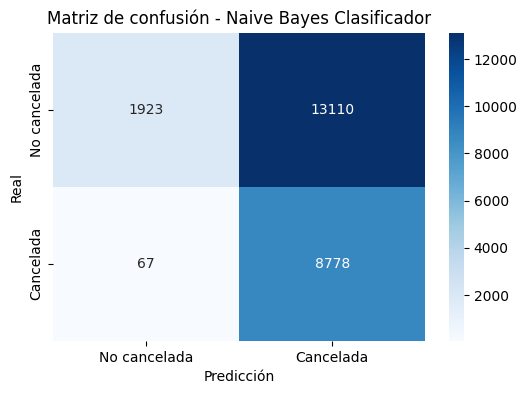

In [9]:
#Visualización de la matriz de confusión
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No cancelada','Cancelada'],
            yticklabels=['No cancelada','Cancelada'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión - Naive Bayes Clasificador')
plt.show()